# Baseline Road Deterioration Models

This notebook trains and evaluates simple baseline models for next-measurement prediction.

Current scope:
- Persistence baseline
- Linear regression
- Ridge regression

Targets:
- `target_next_URA`
- `target_next_IRI`

Rows represent current PTM measurements, and targets are the next PTM measurement within the same lifecycle.

In [158]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [159]:
DATA_PATH = Path("data/road_model_dataset_v1.parquet")
RANDOM_STATE = 42

# To keep the notebook responsive, models are fit on sampled subsets.
# Increase these later if you want to push performance further.
TRAIN_SAMPLE_N = 250_000
TEST_SAMPLE_N = 100_000

# Use the first 80% of unique dates for training and the last 20% for testing.
TRAIN_DATE_QUANTILE = 0.80

In [160]:
use_cols = [
    "Segment_ID",
    "Lifecycle_ID",
    "event_date",
    "KVL",
    "KVL_raskas",
    "KVL_kaista",
    "Nopeus",
    "Toim_lk",
    "Pituus",
    "IRI",
    "URA",
    "Pavement_Age_years",
    "Initial_URA",
    "Measurement_Idx",
    "Minor_TP_Count",
    "tp_count_interval",
    "has_TP_interval",
    "prev_IRI",
    "prev_URA",
    "Delta_t_days",
    "Delta_t_years",
    "target_next_URA",
    "target_next_IRI",
    "target_next_event_date",
    "target_horizon_days",
    "baseline_persist_URA",
    "baseline_persist_IRI",
]

df = pd.read_parquet(DATA_PATH, columns=use_cols)
df["event_date"] = pd.to_datetime(df["event_date"])
df["target_next_event_date"] = pd.to_datetime(df["target_next_event_date"])

print(df.shape)
display(df.head())
print(df[["event_date", "target_next_event_date"]].agg(["min", "max"]))

(3833323, 27)


,Segment_ID,Lifecycle_ID,event_date,KVL,KVL_raskas,KVL_kaista,Nopeus,Toim_lk,Pituus,IRI,URA,Pavement_Age_years,Initial_URA,Measurement_Idx,Minor_TP_Count,tp_count_interval,has_TP_interval,prev_IRI,prev_URA,Delta_t_days,Delta_t_years,target_next_URA,target_next_IRI,target_next_event_date,target_horizon_days,baseline_persist_URA,baseline_persist_IRI
0,Epo_13309_0_11_3_6900_3_7000,Epo_13309_0_11_3_6900_3_7000_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.60,2.7,0.0,2.7,1,1,1,True,NaN,NaN,NaN,NaN,2.7,1.93,2022-08-23,1527.0,2.7,1.60
1,Epo_13309_0_11_3_7000_3_7100,Epo_13309_0_11_3_7000_3_7100_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.50,1.4,0.0,1.4,1,1,1,True,NaN,NaN,NaN,NaN,1.7,1.70,2022-08-23,1527.0,1.4,1.50
2,Epo_13309_0_11_3_7100_3_7200,Epo_13309_0_11_3_7100_3_7200_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.75,1.5,0.0,1.5,1,1,1,True,NaN,NaN,NaN,NaN,1.5,1.91,2022-08-23,1527.0,1.5,1.75
3,Epo_13309_0_11_3_7200_3_7300,Epo_13309_0_11_3_7200_3_7300_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.45,4.7,0.0,4.7,1,1,1,True,NaN,NaN,NaN,NaN,3.5,1.66,2022-08-23,1527.0,4.7,1.45
4,Epo_13309_0_11_3_7300_3_7400,Epo_13309_0_11_3_7300_3_7400_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,2.42,1.4,0.0,1.4,1,1,1,True,NaN,NaN,NaN,NaN,2.0,2.96,2022-08-23,1527.0,1.4,2.42


    event_date target_next_event_date
min 2005-05-19             2011-04-08
max 2023-09-06             2024-09-23


In [161]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Train date range: {train_df['event_date'].min().date()} -> {train_df['event_date'].max().date()}")
print(f"Test date range: {test_df['event_date'].min().date()} -> {test_df['event_date'].max().date()}")

Cutoff date: 2020-08-18
Train rows: 3,096,068
Test rows: 737,255
Train date range: 2005-05-19 -> 2020-08-17
Test date range: 2020-08-18 -> 2023-09-06


In [162]:
def sample_rows(frame: pd.DataFrame, n: int, random_state: int) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n=n, random_state=random_state).copy()


train_sample = sample_rows(train_df, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample = sample_rows(test_df, TEST_SAMPLE_N, RANDOM_STATE)

print(f"Train sample rows: {len(train_sample):,}")
print(f"Test sample rows: {len(test_sample):,}")

Train sample rows: 250,000
Test sample rows: 100,000


In [163]:
def regression_metrics(y_true, y_pred, model_name, target_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "model": model_name,
        "target": target_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_true, y_pred),
    }


results = []

In [164]:
# Persistence baseline
results.append(
    regression_metrics(
        test_sample["target_next_URA"],
        test_sample["baseline_persist_URA"],
        "persistence",
        "target_next_URA",
    )
)

results.append(
    regression_metrics(
        test_sample["target_next_IRI"],
        test_sample["baseline_persist_IRI"],
        "persistence",
        "target_next_IRI",
    )
)

pd.DataFrame(results)

,model,target,mae,rmse,r2
0,persistence,target_next_URA,2.135999,2.714419,0.627201
1,persistence,target_next_IRI,0.220297,0.408800,0.832244


In [165]:
# feature_cols = [
#     "URA",
#     "IRI",
#     "prev_URA",
#     "prev_IRI",
#     "Delta_t_days",
#     "Delta_t_years",
#     "Pavement_Age_years",
#     "Initial_URA",
#     "Measurement_Idx",
#     "Minor_TP_Count",
#     "tp_count_interval",
#     "has_TP_interval",
#     "KVL",
#     "KVL_raskas",
#     "KVL_kaista",
#     "Nopeus",
#     "Pituus",
#     "Toim_lk",
# ]
feature_cols = [
    "URA",
    "IRI",
    "prev_URA",
    "prev_IRI",
    "Delta_t_years",
    "Pavement_Age_years",
    "Initial_URA",
    "Measurement_Idx",
    "Minor_TP_Count",
    "tp_count_interval",
    "has_TP_interval",
    "KVL",
    "KVL_raskas",
    "KVL_kaista",
    "Nopeus",
    "Toim_lk",
]


numeric_features = [c for c in feature_cols if c != "Toim_lk"]
categorical_features = ["Toim_lk"]

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", one_hot),
                ]
            ),
            categorical_features,
        ),
    ]
)

models = {
    "linear_regression": LinearRegression(),
    "ridge_alpha_1": Ridge(alpha=1.0),
}

predictions = {}

In [166]:
for target_name in ["target_next_URA", "target_next_IRI"]:
    train_target = train_sample[target_name].notna()
    test_target = test_sample[target_name].notna()

    X_train = train_sample.loc[train_target, feature_cols]
    y_train = train_sample.loc[train_target, target_name]
    X_test = test_sample.loc[test_target, feature_cols]
    y_test = test_sample.loc[test_target, target_name]

    for model_name, estimator in models.items():
        pipe = Pipeline(
            steps=[
                ("preprocess", preprocess),
                ("model", estimator),
            ]
        )
        # print(feature_cols)
        # print(numeric_features)
        # print(categorical_features)
        # print(X_train.shape)
        # print(X_train.columns.tolist())


        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results.append(regression_metrics(y_test, y_pred, model_name, target_name))
        predictions[(model_name, target_name)] = (y_test, y_pred)

results_df = pd.DataFrame(results).sort_values(["target", "mae", "rmse"]).reset_index(drop=True)
results_df

,model,target,mae,rmse,r2
0,linear_regression,target_next_IRI,0.214211,0.375350,0.858574
1,ridge_alpha_1,target_next_IRI,0.214211,0.375349,0.858574
2,persistence,target_next_IRI,0.220297,0.408800,0.832244
3,ridge_alpha_1,target_next_URA,1.276101,1.813915,0.833523
4,linear_regression,target_next_URA,1.276101,1.813915,0.833523
5,persistence,target_next_URA,2.135999,2.714419,0.627201


In [167]:
summary_table = results_df.pivot(index="model", columns="target", values=["mae", "rmse", "r2"])
summary_table

mae                            rmse                              r2                
target            target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
model                                                                                                            
linear_regression        0.214211        1.276101        0.375350        1.813915        0.858574        0.833523
persistence              0.220297        2.135999        0.408800        2.714419        0.832244        0.627201
ridge_alpha_1            0.214211        1.276101        0.375349        1.813915        0.858574        0.833523

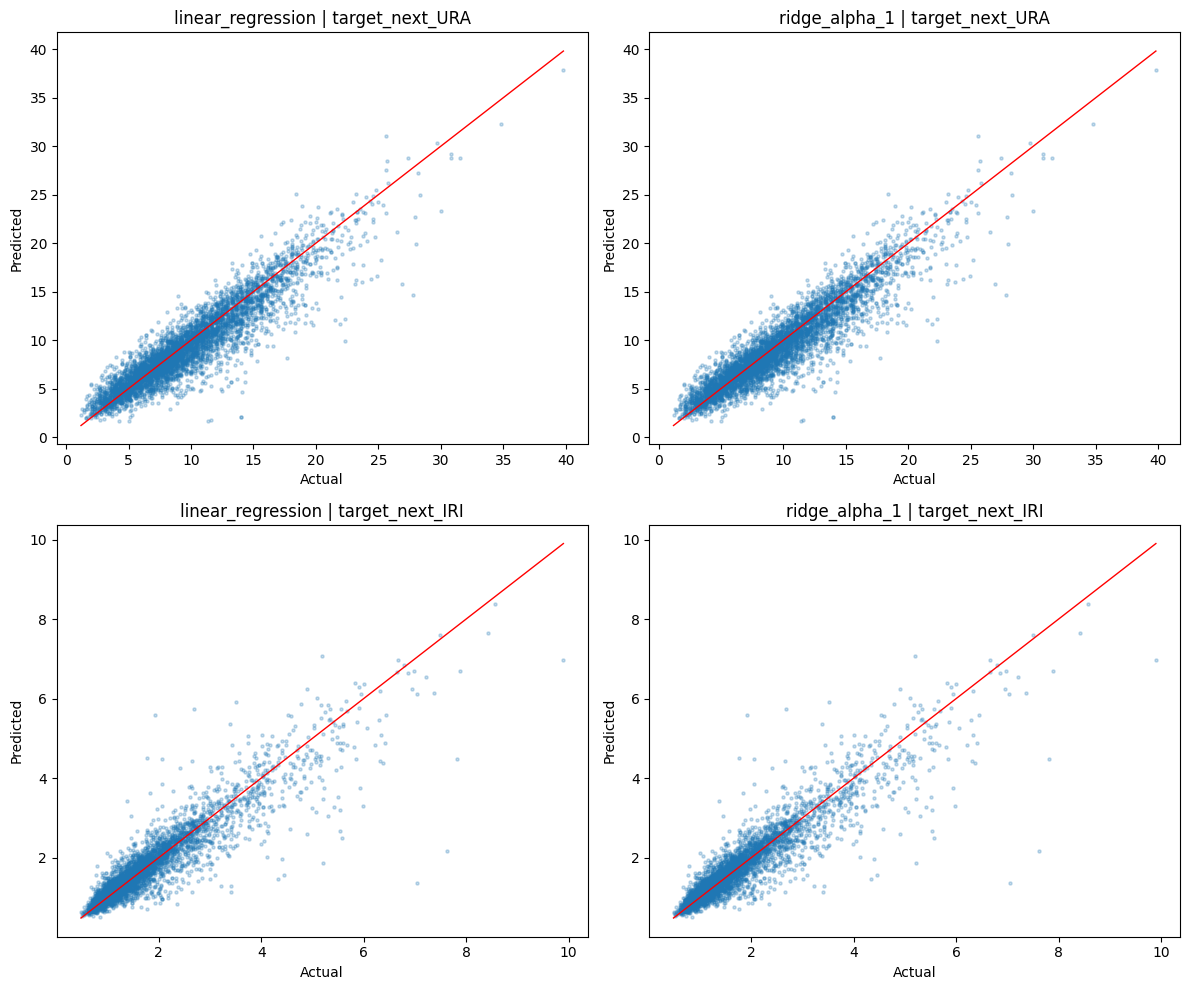

In [168]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_targets = ["target_next_URA", "target_next_IRI"]
plot_models = ["linear_regression", "ridge_alpha_1"]

for row_idx, target_name in enumerate(plot_targets):
    for col_idx, model_name in enumerate(plot_models):
        ax = axes[row_idx, col_idx]
        y_true, y_pred = predictions[(model_name, target_name)]

        plot_df = pd.DataFrame({"actual": y_true, "predicted": y_pred}).sample(
            n=min(5000, len(y_true)),
            random_state=RANDOM_STATE,
        )

        ax.scatter(plot_df["actual"], plot_df["predicted"], s=5, alpha=0.25)
        lo = min(plot_df["actual"].min(), plot_df["predicted"].min())
        hi = max(plot_df["actual"].max(), plot_df["predicted"].max())
        ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
        ax.set_title(f"{model_name} | {target_name}")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

plt.tight_layout()

## Feature Ablation

This section compares nested feature groups for the linear models so we can see where the predictive signal comes from.

In [169]:
def split_valid_feature_groups(frame: pd.DataFrame, selected_features):
    available = [c for c in selected_features if c in frame.columns]
    non_empty = [c for c in available if frame[c].notna().any()]
    dropped_all_missing = [c for c in available if c not in non_empty]
    numeric_features = [c for c in non_empty if c != "Toim_lk"]
    categorical_features = [c for c in ["Toim_lk"] if c in non_empty]
    return {
        "available": available,
        "non_empty": non_empty,
        "dropped_all_missing": dropped_all_missing,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }


def build_preprocessor(feature_groups):
    numeric_features = feature_groups["numeric_features"]
    categorical_features = feature_groups["categorical_features"]
    transformers = []

    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            )
        )

    if categorical_features:
        try:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
        except TypeError:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse=True)

        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", one_hot),
                    ]
                ),
                categorical_features,
            )
        )

    if not transformers:
        raise ValueError("No valid non-empty feature columns were found for preprocessing.")

    return ColumnTransformer(transformers=transformers)


feature_sets = {
    "current_only": [
        "URA",
        "IRI",
    ],
    "current_plus_lag": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
    ],
    "current_lag_lifecycle": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
        "Pavement_Age_years",
        "Initial_URA",
        "Measurement_Idx",
        "Minor_TP_Count",
        "tp_count_interval",
        "has_TP_interval",
    ],
    "current_lag_lifecycle_static": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
        "Pavement_Age_years",
        "Initial_URA",
        "Measurement_Idx",
        "Minor_TP_Count",
        "tp_count_interval",
        "has_TP_interval",
        "KVL",
        "KVL_raskas",
        "KVL_kaista",
        "Nopeus",
        "Toim_lk",
    ],
}

ablation_models = {
    "linear_regression": LinearRegression(),
    "ridge_alpha_1": Ridge(alpha=1.0),
}

ablation_results = []
ablation_predictions = {}
linear_model_fits = {}

In [170]:
for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== Feature set: {feature_set_name} ===")

    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample[target_name].notna()
        test_target = test_sample[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample.columns]
        X_train = train_sample.loc[train_target, active_features].copy()
        y_train = train_sample.loc[train_target, target_name]
        X_test = test_sample.loc[test_target, active_features].copy()
        y_test = test_sample.loc[test_target, target_name]

        train_feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(train_feature_groups)

        print(f"Target: {target_name}")
        print(f"Requested features: {active_features}")
        print(f"Dropped all-missing features: {train_feature_groups['dropped_all_missing']}")

        for model_name, estimator in ablation_models.items():
            pipe = Pipeline(
                steps=[
                    ("preprocess", build_preprocessor(train_feature_groups)),
                    ("model", clone(estimator)),
                ]
            )

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            metrics = regression_metrics(y_test, y_pred, model_name, target_name)
            metrics["feature_set"] = feature_set_name
            metrics["n_features_requested"] = len(active_features)
            metrics["n_features_used"] = len(train_feature_groups["non_empty"])
            ablation_results.append(metrics)

            ablation_predictions[(feature_set_name, model_name, target_name)] = (y_test, y_pred)
            linear_model_fits[(feature_set_name, model_name, target_name)] = pipe

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["target", "feature_set", "mae", "rmse"]
).reset_index(drop=True)
ablation_results_df


=== Feature set: current_only ===
Target: target_next_URA
Requested features: ['URA', 'IRI']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI']
Dropped all-missing features: []

=== Feature set: current_plus_lag ===
Target: target_next_URA
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years']
Dropped all-missing features: []

=== Feature set: current_lag_lifecycle ===
Target: target_next_URA
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years', 'Pavement_Age_years', 'Initial_URA', 'Measurement_Idx', 'Minor_TP_Count', 'tp_count_interval', 'has_TP_interval']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years', 'Pavement_Age_years', 'Initial_URA', 'Measurement_Idx', 'Minor_TP_Count', 'tp_count_i

,model,target,mae,rmse,r2,feature_set,n_features_requested,n_features_used
0,linear_regression,target_next_IRI,0.213309,0.376246,0.857897,current_lag_lifecycle,11,11
1,ridge_alpha_1,target_next_IRI,0.213310,0.376246,0.857897,current_lag_lifecycle,11,11
2,linear_regression,target_next_IRI,0.214211,0.375350,0.858574,current_lag_lifecycle_static,16,16
3,ridge_alpha_1,target_next_IRI,0.214211,0.375349,0.858574,current_lag_lifecycle_static,16,16
4,linear_regression,target_next_IRI,0.224078,0.387546,0.849234,current_only,2,2
5,ridge_alpha_1,target_next_IRI,0.224079,0.387546,0.849234,current_only,2,2
6,linear_regression,target_next_IRI,0.216839,0.377687,0.856807,current_plus_lag,5,5
7,ridge_alpha_1,target_next_IRI,0.216840,0.377687,0.856807,current_plus_lag,5,5
8,ridge_alpha_1,target_next_URA,1.314239,1.854296,0.826028,current_lag_lifecycle,11,11
9,linear_regression,target_next_URA,1.314239,1.854296,0.826028,current_lag_lifecycle,11,11


In [171]:
ablation_summary = ablation_results_df.pivot_table(
    index=["feature_set", "model"],
    columns="target",
    values=["mae", "rmse", "r2"],
)
ablation_summary

mae                              r2                            rmse                
target                                         target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                            
current_lag_lifecycle        linear_regression        0.213309        1.314239        0.857897        0.826028        0.376246        1.854296
                             ridge_alpha_1            0.213310        1.314239        0.857897        0.826028        0.376246        1.854296
current_lag_lifecycle_static linear_regression        0.214211        1.276101        0.858574        0.833523        0.375350        1.813915
                             ridge_alpha_1            0.214211        1.276101        0.858574        0.833523        0.375349        1.813915
current_only                 linear_regression        0.224078        1.324100        0.849234        0.823382        0.387546        1.868343
                             ridge_alpha_1            0.224079        1.324100        0.849234        0.823382        0.387546        1.868343
current_plus_lag             linear_regression        0.216839        1.308134        0.856807        0.828377        0.377687        1.841733
                             ridge_alpha_1            0.216840        1.308135        0.856807        0.828377        0.377687        1.841733

## Linear Coefficient Inspection

These cells inspect the fitted coefficients for the linear models. Because preprocessing includes scaling and one-hot encoding, the coefficients are shown in transformed-feature space.

In [172]:
def get_transformed_feature_names(pipe):
    preprocess = pipe.named_steps["preprocess"]
    try:
        return preprocess.get_feature_names_out()
    except AttributeError:
        feature_names = []
        for name, transformer, cols in preprocess.transformers_:
            if name == "remainder":
                continue
            if hasattr(transformer, "get_feature_names_out"):
                feature_names.extend(transformer.get_feature_names_out(cols))
            else:
                feature_names.extend(cols)
        return np.array(feature_names)


def coefficient_table(pipe):
    model = pipe.named_steps["model"]
    feature_names = get_transformed_feature_names(pipe)
    coef = np.ravel(model.coef_)
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef,
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    return coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)


best_linear_keys = {}
for target_name in ["target_next_URA", "target_next_IRI"]:
    target_rows = ablation_results_df.loc[
        (ablation_results_df["target"] == target_name)
        & (ablation_results_df["model"] == "linear_regression")
    ].sort_values("rmse")
    best_row = target_rows.iloc[0]
    best_linear_keys[target_name] = (
        best_row["feature_set"],
        best_row["model"],
        target_name,
    )

best_linear_keys

{'target_next_URA': ('current_lag_lifecycle_static',
  'linear_regression',
  'target_next_URA'),
 'target_next_IRI': ('current_lag_lifecycle_static',
  'linear_regression',
  'target_next_IRI')}

In [173]:
for target_name, fit_key in best_linear_keys.items():
    print(f"\nTop coefficients for {target_name} using {fit_key[0]}:")
    display(coefficient_table(linear_model_fits[fit_key]).head(20))


Top coefficients for target_next_URA using current_lag_lifecycle_static:


,feature,coefficient,abs_coefficient
0,num__URA,3.734038,3.734038
1,num__KVL_kaista,0.453595,0.453595
2,num__Measurement_Idx,-0.289883,0.289883
3,num__prev_URA,0.266519,0.266519
4,num__tp_count_interval,0.204794,0.204794
5,num__has_TP_interval,-0.199419,0.199419
6,num__Delta_t_years,0.154940,0.154940
7,num__KVL,-0.139736,0.139736
8,cat__Toim_lk_seutu,-0.117700,0.117700
9,cat__Toim_lk_kanta,0.112945,0.112945



Top coefficients for target_next_IRI using current_lag_lifecycle_static:


,feature,coefficient,abs_coefficient
0,num__IRI,0.830327,0.830327
1,cat__Toim_lk_yhdys,0.123254,0.123254
2,num__prev_IRI,0.108338,0.108338
3,cat__Toim_lk_valta,-0.068779,0.068779
4,num__URA,0.054708,0.054708
5,num__Measurement_Idx,-0.054157,0.054157
6,cat__Toim_lk_kanta,-0.047932,0.047932
7,num__Pavement_Age_years,0.034003,0.034003
8,num__prev_URA,-0.019178,0.019178
9,num__KVL_kaista,-0.013592,0.013592


## Notes for next iteration

- Compare whether static variables actually improve over current-condition persistence.
- Try a reduced feature set with only current value and delta-time first.
- If linear models underperform persistence, the next step should be a tree-based baseline such as `HistGradientBoostingRegressor`.
- Later, add richer lifecycle-history features or explicit TP-event history.